Loaded 16 Flame Spectrometer files for MgSO4.


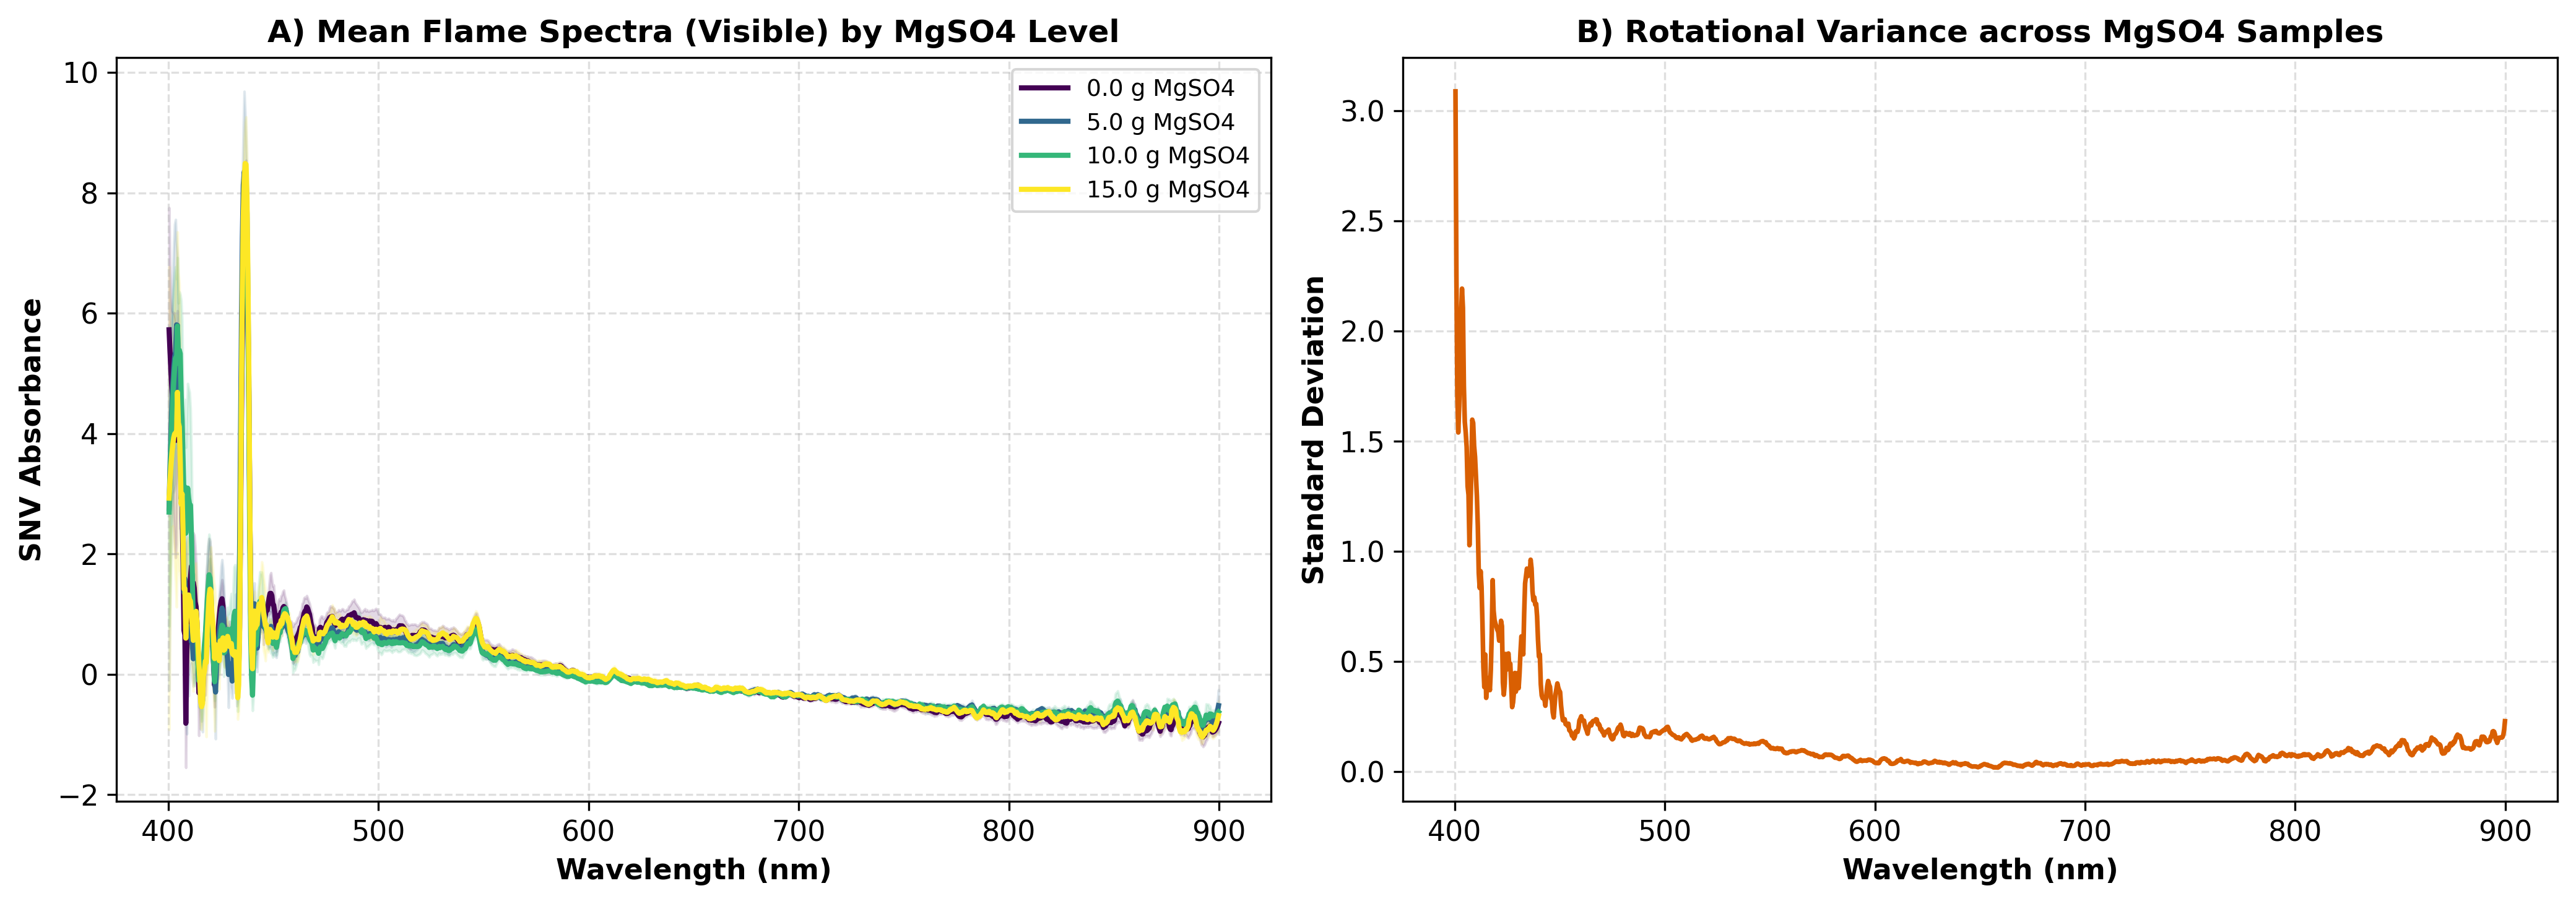


FLAME SPECTROMETER MgSO4 PLSR METRICS (N = 16)
Calibration R²   (R²_cal)  : 0.6934
Calibration RMSE (RMSEC)   : 3.0955 g
Validation R²    (R²_cv)   : -0.7169
Validation RMSE  (RMSECV)  : 7.3248 g

Individual Validation Errors:
0g_MgSO4_15ml_0_ang.txt          | Actual:  0.0g | Predicted:  6.03g | Error: 6.03g <--- HIGH ERROR
0g_MgSO4_15ml_180_ang.txt        | Actual:  0.0g | Predicted:  8.33g | Error: 8.33g <--- HIGH ERROR
0g_MgSO4_15ml_270_ang.txt        | Actual:  0.0g | Predicted: 10.04g | Error: 10.04g <--- HIGH ERROR
0g_MgSO4_15ml_90_ang.txt         | Actual:  0.0g | Predicted:  6.53g | Error: 6.53g <--- HIGH ERROR
10g_MgSO4_15ml_0_ang.txt         | Actual: 10.0g | Predicted:  6.90g | Error: 3.10g <--- HIGH ERROR
10g_MgSO4_15ml_180_ang.txt       | Actual: 10.0g | Predicted:  7.12g | Error: 2.88g
10g_MgSO4_15ml_270_ang.txt       | Actual: 10.0g | Predicted:  2.19g | Error: 7.81g <--- HIGH ERROR
10g_MgSO4_15ml_90_ang.txt        | Actual: 10.0g | Predicted:  4.84g | Error: 5.16g <--

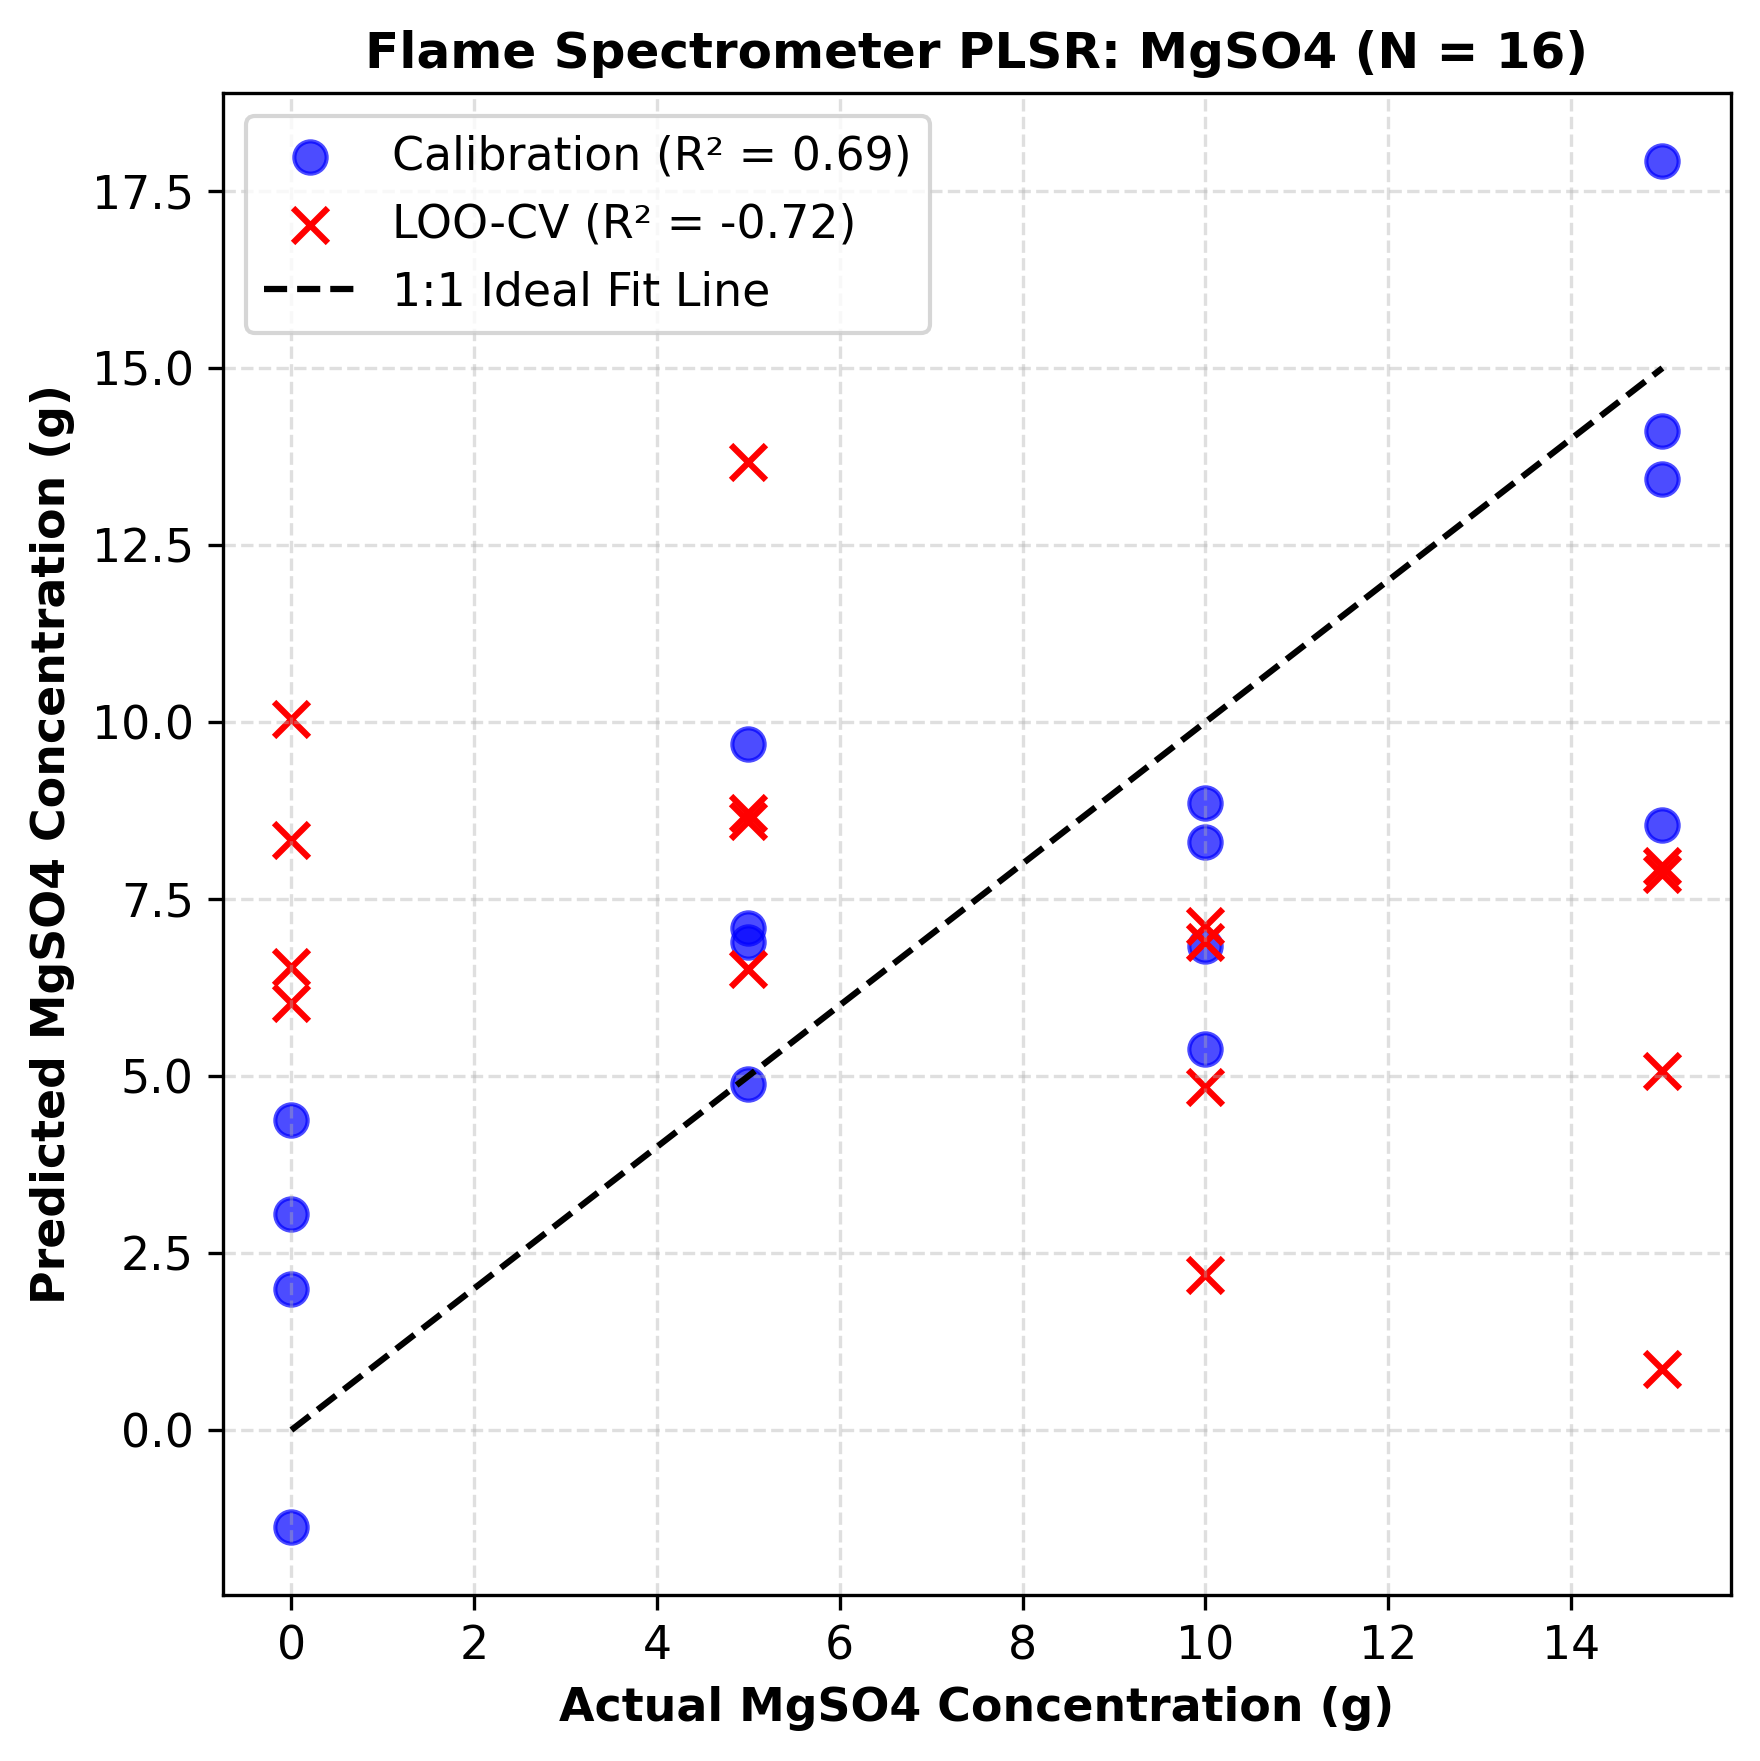

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

def apply_snv(X_data):
    X_snv = np.zeros_like(X_data)
    for i in range(X_data.shape[0]):
        X_snv[i] = (X_data[i] - np.mean(X_data[i])) / np.std(X_data[i])
    return X_snv

# ==========================================
# 1. LOAD FLAME SPECTROMETER DATA (N = 16)
# =========================================
# path MgSO4 directory
DATA_FOLDER = "."  
COMPOUND_NAME = "MgSO4"  

file_paths = glob.glob(os.path.join(DATA_FOLDER, "*.txt"))

wavelengths = None
raw_absorbance_list = []
labels = []
filenames = []

for filepath in file_paths:
    fname = os.path.basename(filepath)
    fname_lower = fname.lower()
    
    if 'control' in fname_lower or 'blank' in fname_lower:
        conc = 0.0
    else:
        match = re.search(r'(\d+(?:\.\d+)?)\s*g', fname_lower)
        if match:
            conc = float(match.group(1))
        else:
            continue
    
    try:
        data = pd.read_csv(filepath, sep=r'\s+', skiprows=14, header=None, comment='>')
        data = data.dropna().apply(pd.to_numeric, errors='coerce').dropna()
    except Exception:
        data = np.loadtxt(filepath, skiprows=17)
    
    wl = data.iloc[:, 0].values if isinstance(data, pd.DataFrame) else data[:, 0]
    ref = data.iloc[:, 1].values if isinstance(data, pd.DataFrame) else data[:, 1]
    
    # Mask to stable Flame/Visible spectrometer window (400 nm - 900 nm)
    mask = (wl >= 400) & (wl <= 900)
    if wavelengths is None:
        wavelengths = wl[mask]
        
    ref_clipped = np.clip(ref[mask], 0.01, 100.0)
    abs_spectrum = np.log10(100.0 / ref_clipped)
    
    raw_absorbance_list.append(abs_spectrum)
    labels.append(conc)
    filenames.append(fname)

X_raw = np.array(raw_absorbance_list)
y = np.array(labels)

print(f"Loaded {len(y)} Flame Spectrometer files for {COMPOUND_NAME}.")

# ==========================================
# 2. PREPROCESSING (SG + SNV)
# ==========================================
X_sg = np.array([savgol_filter(spec, window_length=15, polyorder=2) for spec in X_raw])
X = apply_snv(X_sg)

# ==========================================
# 3. SPECTRAL PLOTS (VISIBLE RANGE)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
unique_levels = sorted(list(set(y)))
colors = ['#440154', '#31688e', '#35b779', '#fde725']

for idx, level in enumerate(unique_levels):
    mask = (y == level)
    mean_spec = np.mean(X[mask], axis=0)
    std_spec = np.std(X[mask], axis=0)
    
    ax1.plot(wavelengths, mean_spec, label=f"{level:.1f} g {COMPOUND_NAME}", color=colors[idx], linewidth=2.0)
    ax1.fill_between(wavelengths, mean_spec - std_spec, mean_spec + std_spec, color=colors[idx], alpha=0.15)

ax1.set_xlabel("Wavelength (nm)", fontweight='bold')
ax1.set_ylabel("SNV Absorbance", fontweight='bold')
ax1.set_title(f"A) Mean Flame Spectra (Visible) by {COMPOUND_NAME} Level", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', frameon=True, fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

overall_std = np.std(X, axis=0)
ax2.plot(wavelengths, overall_std, color='#d95f02', linewidth=1.8)
ax2.set_xlabel("Wavelength (nm)", fontweight='bold')
ax2.set_ylabel("Standard Deviation", fontweight='bold')
ax2.set_title(f"B) Rotational Variance across {COMPOUND_NAME} Samples", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f"Flame_{COMPOUND_NAME}_Spectra.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. PLSR MODEL & LOO-CV
# ==========================================
n_components = 2
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)
y_cal = pls.predict(X).ravel()
r2_cal = r2_score(y, y_cal)
rmsec = np.sqrt(mean_squared_error(y, y_cal))

loo = LeaveOneOut()
y_cv = np.zeros_like(y)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model_cv = PLSRegression(n_components=n_components)
    model_cv.fit(X_train, y_train)
    y_cv[test_idx] = model_cv.predict(X_test).ravel()

r2_cv = r2_score(y, y_cv)
rmsecv = np.sqrt(mean_squared_error(y, y_cv))

print("\n" + "="*50)
print(f"FLAME SPECTROMETER {COMPOUND_NAME} PLSR METRICS (N = {len(y)})")
print("="*50)
print(f"Calibration R²   (R²_cal)  : {r2_cal:.4f}")
print(f"Calibration RMSE (RMSEC)   : {rmsec:.4f} g")
print(f"Validation R²    (R²_cv)   : {r2_cv:.4f}")
print(f"Validation RMSE  (RMSECV)  : {rmsecv:.4f} g")
print("="*50)

print("\nIndividual Validation Errors:")
for fname, actual, pred in zip(filenames, y, y_cv):
    err = abs(actual - pred)
    flag = " <--- HIGH ERROR" if err > 3.0 else ""
    print(f"{fname:<32} | Actual: {actual:>4.1f}g | Predicted: {pred:>5.2f}g | Error: {err:>4.2f}g{flag}")

# ==========================================
# 5. REGRESSION SCATTER PLOT
# ==========================================
plt.figure(figsize=(6, 6), dpi=300)
plt.scatter(y, y_cal, color='blue', label=f'Calibration (R² = {r2_cal:.2f})', alpha=0.7, s=60)
plt.scatter(y, y_cv, color='red', marker='x', label=f'LOO-CV (R² = {r2_cv:.2f})', s=70)
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='1:1 Ideal Fit Line')

plt.xlabel(f"Actual {COMPOUND_NAME} Concentration (g)", fontweight='bold')
plt.ylabel(f"Predicted {COMPOUND_NAME} Concentration (g)", fontweight='bold')
plt.title(f"Flame Spectrometer PLSR: {COMPOUND_NAME} (N = {len(y)})", fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f"Flame_{COMPOUND_NAME}_PLSR.png", dpi=300, bbox_inches='tight')
plt.show()

Loaded 16 Flame Spectrometer files for MgSO4 (Range: 500-880 nm).


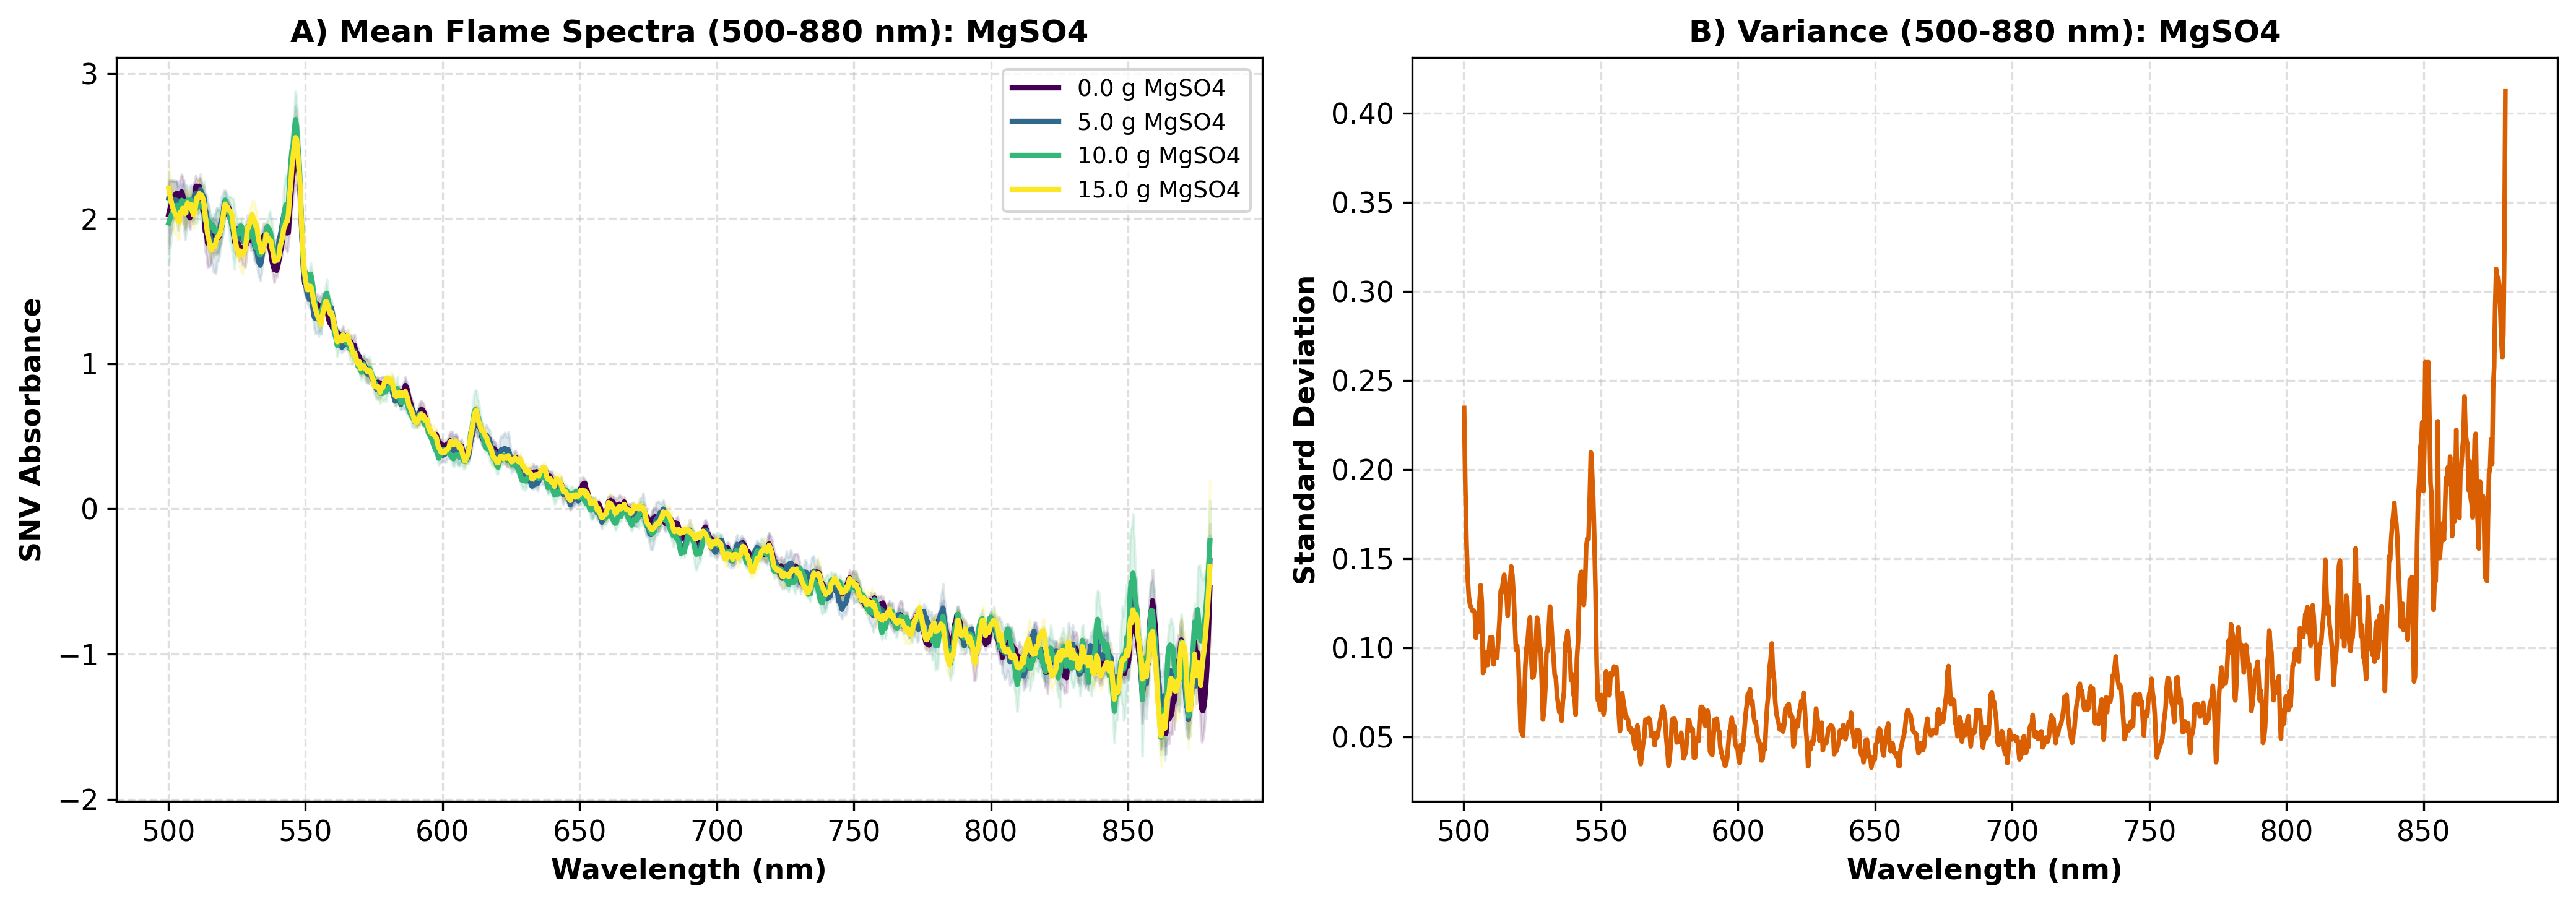


TRUNCATED FLAME SPECTROMETER MgSO4 METRICS (N = 16)
Calibration R²   (R²_cal)  : 0.9337
Calibration RMSE (RMSEC)   : 1.4398 g
Validation R²    (R²_cv)   : -0.3925
Validation RMSE  (RMSECV)  : 6.5968 g


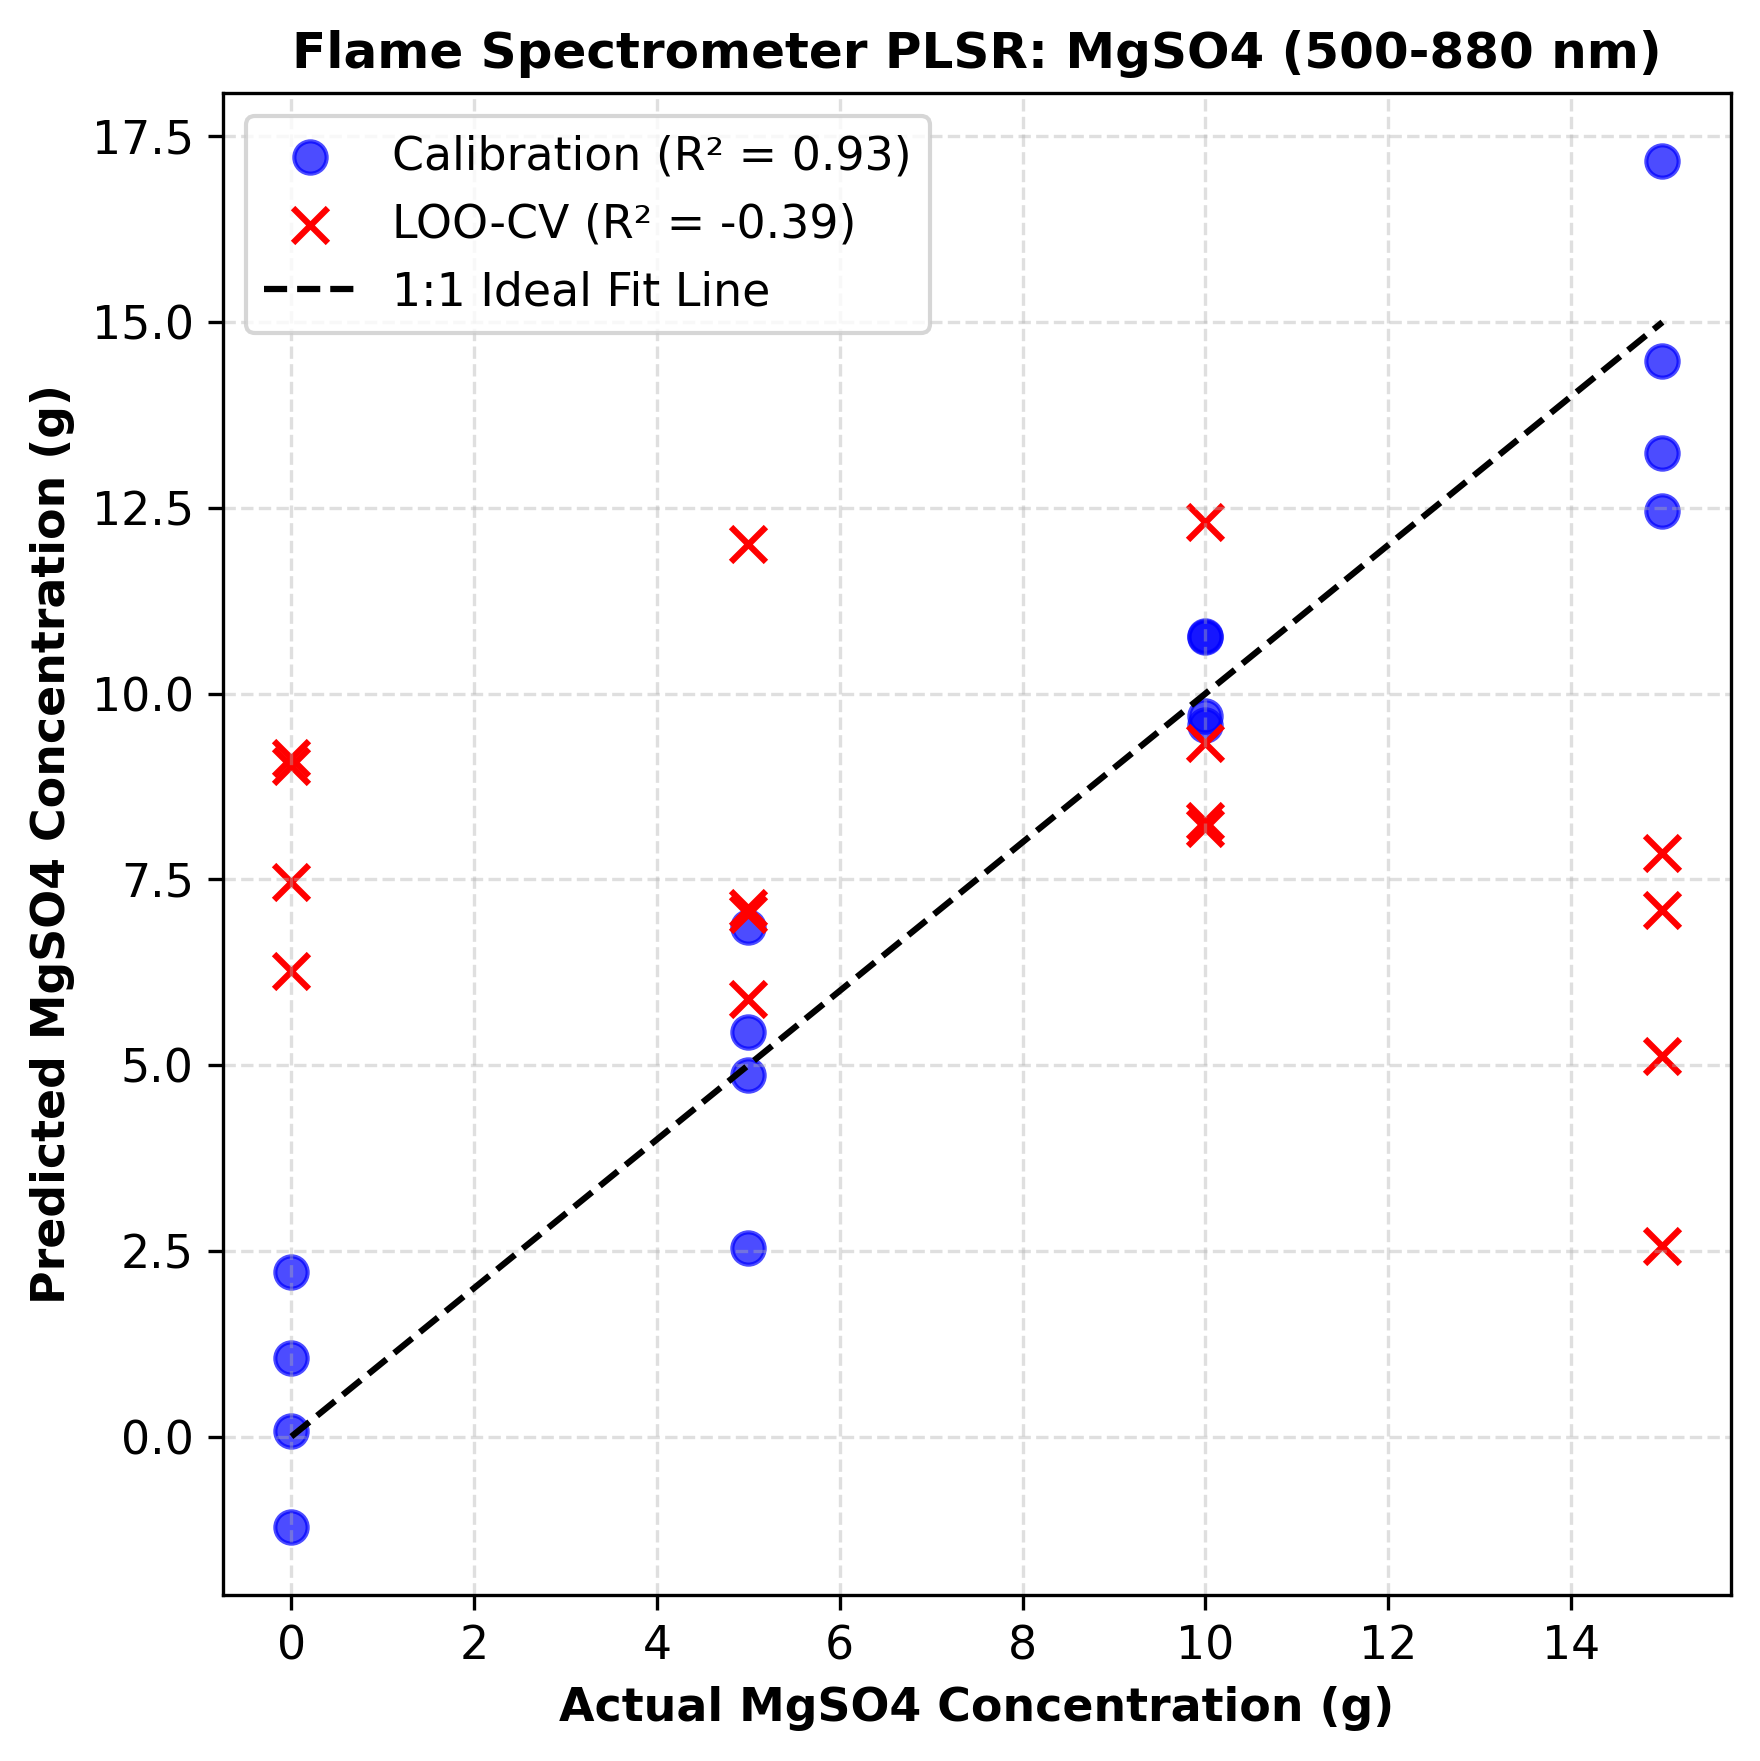

In [2]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

def apply_snv(X_data):
    X_snv = np.zeros_like(X_data)
    for i in range(X_data.shape[0]):
        X_snv[i] = (X_data[i] - np.mean(X_data[i])) / np.std(X_data[i])
    return X_snv

# ==========================================
# 1. LOAD FLAME SPECTROMETER MgSO4 DATA
# ==========================================
DATA_FOLDER = "."  # Path to Flame MgSO4 files
COMPOUND_NAME = "MgSO4"

file_paths = glob.glob(os.path.join(DATA_FOLDER, "*.txt"))

wavelengths = None
raw_absorbance_list = []
labels = []
filenames = []

for filepath in file_paths:
    fname = os.path.basename(filepath)
    fname_lower = fname.lower()
    
    if 'control' in fname_lower or 'blank' in fname_lower:
        conc = 0.0
    else:
        match = re.search(r'(\d+(?:\.\d+)?)\s*g', fname_lower)
        if match:
            conc = float(match.group(1))
        else:
            continue
    
    try:
        data = pd.read_csv(filepath, sep=r'\s+', skiprows=14, header=None, comment='>')
        data = data.dropna().apply(pd.to_numeric, errors='coerce').dropna()
    except Exception:
        data = np.loadtxt(filepath, skiprows=17)
    
    wl = data.iloc[:, 0].values if isinstance(data, pd.DataFrame) else data[:, 0]
    ref = data.iloc[:, 1].values if isinstance(data, pd.DataFrame) else data[:, 1]
    
    # TRUNCATE NOISE: Mask to clean visible/NIR window (500 nm - 880 nm)
    mask = (wl >= 500) & (wl <= 880)
    if wavelengths is None:
        wavelengths = wl[mask]
        
    ref_clipped = np.clip(ref[mask], 0.01, 100.0)
    abs_spectrum = np.log10(100.0 / ref_clipped)
    
    raw_absorbance_list.append(abs_spectrum)
    labels.append(conc)
    filenames.append(fname)

X_raw = np.array(raw_absorbance_list)
y = np.array(labels)

print(f"Loaded {len(y)} Flame Spectrometer files for {COMPOUND_NAME} (Range: 500-880 nm).")

# ==========================================
# 2. PREPROCESSING (SG + SNV)
# ==========================================
X_sg = np.array([savgol_filter(spec, window_length=15, polyorder=2) for spec in X_raw])
X = apply_snv(X_sg)

# ==========================================
# 3. SPECTRAL PLOTS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
unique_levels = sorted(list(set(y)))
colors = ['#440154', '#31688e', '#35b779', '#fde725']

for idx, level in enumerate(unique_levels):
    mask = (y == level)
    mean_spec = np.mean(X[mask], axis=0)
    std_spec = np.std(X[mask], axis=0)
    
    ax1.plot(wavelengths, mean_spec, label=f"{level:.1f} g {COMPOUND_NAME}", color=colors[idx], linewidth=2.0)
    ax1.fill_between(wavelengths, mean_spec - std_spec, mean_spec + std_spec, color=colors[idx], alpha=0.15)

ax1.set_xlabel("Wavelength (nm)", fontweight='bold')
ax1.set_ylabel("SNV Absorbance", fontweight='bold')
ax1.set_title(f"A) Mean Flame Spectra (500-880 nm): {COMPOUND_NAME}", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', frameon=True, fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

overall_std = np.std(X, axis=0)
ax2.plot(wavelengths, overall_std, color='#d95f02', linewidth=1.8)
ax2.set_xlabel("Wavelength (nm)", fontweight='bold')
ax2.set_ylabel("Standard Deviation", fontweight='bold')
ax2.set_title(f"B) Variance (500-880 nm): {COMPOUND_NAME}", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f"Flame_{COMPOUND_NAME}_Clean_Spectra.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. PLSR MODEL & LOO-CV
# ==========================================
n_components = 2
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)
y_cal = pls.predict(X).ravel()
r2_cal = r2_score(y, y_cal)
rmsec = np.sqrt(mean_squared_error(y, y_cal))

loo = LeaveOneOut()
y_cv = np.zeros_like(y)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model_cv = PLSRegression(n_components=n_components)
    model_cv.fit(X_train, y_train)
    y_cv[test_idx] = model_cv.predict(X_test).ravel()

r2_cv = r2_score(y, y_cv)
rmsecv = np.sqrt(mean_squared_error(y, y_cv))

print("\n" + "="*50)
print(f"TRUNCATED FLAME SPECTROMETER {COMPOUND_NAME} METRICS (N = {len(y)})")
print("="*50)
print(f"Calibration R²   (R²_cal)  : {r2_cal:.4f}")
print(f"Calibration RMSE (RMSEC)   : {rmsec:.4f} g")
print(f"Validation R²    (R²_cv)   : {r2_cv:.4f}")
print(f"Validation RMSE  (RMSECV)  : {rmsecv:.4f} g")
print("="*50)

# ==========================================
# 5. REGRESSION SCATTER PLOT
# ==========================================
plt.figure(figsize=(6, 6), dpi=300)
plt.scatter(y, y_cal, color='blue', label=f'Calibration (R² = {r2_cal:.2f})', alpha=0.7, s=60)
plt.scatter(y, y_cv, color='red', marker='x', label=f'LOO-CV (R² = {r2_cv:.2f})', s=70)
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='1:1 Ideal Fit Line')

plt.xlabel(f"Actual {COMPOUND_NAME} Concentration (g)", fontweight='bold')
plt.ylabel(f"Predicted {COMPOUND_NAME} Concentration (g)", fontweight='bold')
plt.title(f"Flame Spectrometer PLSR: {COMPOUND_NAME} (500-880 nm)", fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f"Flame_{COMPOUND_NAME}_Clean_PLSR.png", dpi=300, bbox_inches='tight')
plt.show()